# XGBOOST Model - Analysis + Optimisation pour réduire les coûts

## imports bibli

In [1]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, f1_score, precision_score, recall_score
from sklearn.model_selection import RandomizedSearchCV

## Chargement des données 

In [ ]:
train_df = pd.read_csv('../data/data_prep_1/train_1.csv')
val_df   = pd.read_csv('../data/data_prep_1/val_1.csv')
test_df  = pd.read_csv('../data/data_prep_1/test_1.csv')
#
target = 'target_is_fraud'

In [3]:
test_df.head()

,customer_id,age,tenure_months,annual_income_eur,credit_score,num_transactions_30d,avg_amount_30d_eur,max_amount_30d_eur,days_since_last_login,support_tickets_90d,...,device_trust_z,ip_risk_z,is_vpn,num_devices_30d,is_new_device,terms_accepted_flag,has_second_email,is_missing_max_amount_30d_eur,is_new_device_x_num_devices,is_vpn_x_ip_risk
0,CUST_E5RX1BC9II,0.414825,1.961606,-0.525930,-0.518890,0.425572,1.077000,1.883261,-0.379964,-0.892175,...,-1.182449,-1.944043,-0.295244,-0.645137,2.129361,0.0,-0.293395,0.0,1.007575,-0.000954
1,CUST_BHWIUKERGN,-1.405822,-0.726191,0.373215,0.482149,-0.213303,-0.179870,-0.180370,-0.629415,0.225522,...,-1.011968,0.433415,-0.295244,-0.645137,-0.469624,0.0,-0.293395,0.0,-0.398579,-0.000954
2,CUST_EXT9NA4CHU,0.328128,-0.894178,-0.023623,1.583292,-1.065136,-0.414035,-0.235650,-0.379964,0.225522,...,0.930518,-0.105142,-0.295244,0.485381,-0.469624,0.0,-0.293395,0.0,-0.398579,-0.000954
3,CUST_9FSJE5R1NY,0.068035,0.113746,-0.312591,-1.620033,1.490364,-0.560238,0.087012,1.366192,-0.892175,...,-1.061107,-0.779840,-0.295244,-0.645137,-0.469624,0.0,-0.293395,0.0,-0.398579,-0.000954
4,CUST_GDQXMODBED,1.368497,-0.446212,-0.084933,-0.769150,-0.213303,0.221830,0.942135,0.784140,-0.892175,...,1.015759,-1.401482,-0.295244,-0.645137,-0.469624,0.0,-0.293395,0.0,-0.398579,-0.000954


## Séparation features et target

In [4]:
X_train = train_df.drop(columns=[target])
y_train = train_df[target]

# VAL : retirer customer_id si présent
if 'customer_id' in val_df.columns:
    X_val = val_df.drop(columns=[target, 'customer_id'])
else:
    X_val = val_df.drop(columns=[target])
y_val = val_df[target]

# TEST : garder customer_id séparément pour la submission finale
customer_ids = test_df['customer_id']
X_test = test_df.drop(columns=['customer_id'])

In [5]:
param_grid = {
    'n_estimators': [50, 100, 150],          # ← RÉDUIT (moins d'arbres)
    'max_depth': [2, 3, 4],                  # ← TRÈS BAS (arbres peu profonds)
    'learning_rate': [0.01, 0.05],           # ← PLUS LENT (apprend moins vite)
    'subsample': [0.5, 0.6, 0.7],            # ← BAS (50-70% des lignes)
    'colsample_bytree': [0.5, 0.6, 0.7],     # ← BAS (50-70% des features)
    'min_child_weight': [5, 7, 10],          # ← TRÈS HAUT (feuilles lourdes)
    'gamma': [0.3, 0.5, 0.7],                # ← TRÈS HAUT (pénalise les splits)
    'reg_alpha': [1, 2, 3],                  # ← TRÈS HAUT (L1 fort)
    'reg_lambda': [3, 5, 7]                  # ← TRÈS HAUT (L2 fort)
}

In [6]:
# 5. CRÉATION DU MODÈLE DE BASE
# On définit les paramètres fixes qui ne seront pas tunés
# ═════════════════════════════════════════════════════════════════════════════
base_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric='aucpr',
    tree_method='hist',                      # accélère l'entraînement
    n_jobs=-1                                # utilise tous les CPU
)

In [7]:
# ═════════════════════════════════════════════════════════════════════════════
# ÉTAPE 5 : RANDOMIZED SEARCH POUR TROUVER LES MEILLEURS HYPERPARAMÈTRES
# n_iter=15 : teste 15 combinaisons aléatoires
# cv=2 : validation croisée 2-fold (balance vitesse/fiabilité)
# scoring='f1' : optimise le F1-Score
# ═════════════════════════════════════════════════════════════════════════════
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_grid,
    n_iter=50,
    cv=2,
    scoring='f1',
    verbose=2,
    n_jobs=-1,
    random_state=42
)

print("\n" + "="*70)
print("DÉBUT DU TUNING (estimation: 15-20 min)")
print("="*70 + "\n")

random_search.fit(X_train, y_train)


DÉBUT DU TUNING (estimation: 15-20 min)

Fitting 2 folds for each of 50 candidates, totalling 100 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.5, 0.6, ...], 'gamma': [0.3, 0.5, ...], 'learning_rate': [0.01, 0.05], 'max_depth': [2, 3, ...], ...}"
,n_iter,50
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,2
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [8]:
# ÉTAPE 6 : AFFICHAGE DES MEILLEURS HYPERPARAMÈTRES TROUVÉS
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("MEILLEURS PARAMÈTRES TROUVÉS :")
print("="*70)
for param, value in random_search.best_params_.items():
    print(f"{param:20s} : {value}")

print("\n" + "="*70)
print(f"MEILLEUR F1-SCORE (train avec CV) : {random_search.best_score_:.4f}")
print("="*70)

best_model = random_search.best_estimator_


MEILLEURS PARAMÈTRES TROUVÉS :
subsample            : 0.6
reg_lambda           : 3
reg_alpha            : 2
n_estimators         : 150
min_child_weight     : 7
max_depth            : 4
learning_rate        : 0.05
gamma                : 0.3
colsample_bytree     : 0.6

MEILLEUR F1-SCORE (train avec CV) : 0.8635


In [9]:
y_train_pred = best_model.predict(X_train)
y_val_pred = best_model.predict(X_val)

f1_train = f1_score(y_train, y_train_pred)
f1_val = f1_score(y_val, y_val_pred)

print("\n" + "="*70)
print("DÉTECTION D'OVERFIT :")
print("="*70)
print(f"F1-Score TRAIN : {f1_train:.4f}")
print(f"F1-Score VAL   : {f1_val:.4f}")
print(f"Écart          : {f1_train - f1_val:.4f}")

if f1_train - f1_val > 0.15:
    print("⚠️  OVERFIT DÉTECTÉ ! Écart > 0.15")
elif f1_train - f1_val > 0.10:
    print("⚠️  Léger overfit (écart entre 0.10 et 0.15)")
else:
    print("✅ Pas d'overfit majeur (écart < 0.10)")


DÉTECTION D'OVERFIT :
F1-Score TRAIN : 0.8694
F1-Score VAL   : 0.4073
Écart          : 0.4621
⚠️  OVERFIT DÉTECTÉ ! Écart > 0.15


In [10]:
# ÉTAPE 8 : OPTIMISATION DU SEUIL DE DÉCISION
# Le seuil par défaut (0.5) n'est pas optimal pour la fraude
# On teste différents seuils pour maximiser le F1-Score
# Seuil bas → détecte plus de fraudes (recall ↑) mais plus de faux positifs
# Seuil haut → moins de faux positifs (precision ↑) mais rate des fraudes
# ═════════════════════════════════════════════════════════════════════════════
y_val_proba = best_model.predict_proba(X_val)[:, 1]

print("\n" + "="*70)
print("OPTIMISATION DU SEUIL DE DÉCISION :")
print("="*70)
print(f"{'Seuil':<8} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-"*70)

best_f1 = 0
best_threshold = 0.5

for threshold in np.arange(0.2, 0.6, 0.01):
    y_pred_thresh = (y_val_proba >= threshold).astype(int)
    
    precision = precision_score(y_val, y_pred_thresh)
    recall = recall_score(y_val, y_pred_thresh)
    f1 = f1_score(y_val, y_pred_thresh)
    
    print(f"{threshold:<8.2f} {precision:<12.4f} {recall:<12.4f} {f1:<12.4f}")
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("-"*70)
print(f"🎯 MEILLEUR SEUIL : {best_threshold:.2f} avec F1 = {best_f1:.4f}")
print("="*70)


OPTIMISATION DU SEUIL DE DÉCISION :
Seuil    Precision    Recall       F1-Score    
----------------------------------------------------------------------
0.20     0.1540       0.9198       0.2639      
0.21     0.1579       0.9114       0.2692      
0.22     0.1620       0.9049       0.2748      
0.23     0.1658       0.8969       0.2799      
0.24     0.1702       0.8911       0.2858      
0.25     0.1739       0.8824       0.2906      
0.26     0.1778       0.8726       0.2955      
0.27     0.1815       0.8642       0.3000      
0.28     0.1858       0.8588       0.3055      
0.29     0.1900       0.8508       0.3106      
0.30     0.1954       0.8454       0.3174      
0.31     0.2000       0.8370       0.3229      
0.32     0.2042       0.8301       0.3278      
0.33     0.2089       0.8218       0.3331      
0.34     0.2135       0.8123       0.3382      
0.35     0.2174       0.8015       0.3421      
0.36     0.2221       0.7938       0.3471      
0.37     0.2272       0.7851

In [11]:
# ÉTAPE 9 : ÉVALUATION FINALE SUR VAL AVEC LE MEILLEUR SEUIL
# ═════════════════════════════════════════════════════════════════════════════
y_val_pred_final = (y_val_proba >= best_threshold).astype(int)

print("\n" + "="*70)
print(f"ÉVALUATION FINALE SUR VAL (seuil = {best_threshold:.2f}) :")
print("="*70)
print(f"Accuracy  : {accuracy_score(y_val, y_val_pred_final):.4f}")
print(f"F1-Score  : {f1_score(y_val, y_val_pred_final):.4f}")
print(f"Precision : {precision_score(y_val, y_val_pred_final):.4f}")
print(f"Recall    : {recall_score(y_val, y_val_pred_final):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_val, y_val_proba):.4f}")
print("\nRapport de classification :")
print(classification_report(y_val, y_val_pred_final))


ÉVALUATION FINALE SUR VAL (seuil = 0.58) :
Accuracy  : 0.8760
F1-Score  : 0.4177
Precision : 0.3507
Recall    : 0.5165
ROC-AUC   : 0.8437

Rapport de classification :
              precision    recall  f1-score   support

           0       0.95      0.91      0.93     29245
           1       0.35      0.52      0.42      2755

    accuracy                           0.88     32000
   macro avg       0.65      0.71      0.67     32000
weighted avg       0.90      0.88      0.89     32000



In [12]:
# ÉTAPE 10 : PRÉDICTIONS FINALES SUR TEST AVEC LE MEILLEUR SEUIL
# On applique le seuil optimisé trouvé sur val pour prédire sur test
# ═════════════════════════════════════════════════════════════════════════════
test_pred_proba = best_model.predict_proba(X_test)[:, 1]
test_pred = (test_pred_proba >= best_threshold).astype(int)

submission = pd.DataFrame({
    'customer_id': customer_ids,
    'target_is_fraud': test_pred
})

submission.to_csv('submission_test.csv', index=False)

print("\n" + "="*70)
print("SUBMISSION CRÉÉE : submission_optimized.csv")
print("="*70)
print(submission.head(10))
print(f"\nNombre total de prédictions : {len(submission)}")
print(f"Fraudes détectées : {test_pred.sum()} ({test_pred.sum()/len(test_pred)*100:.2f}%)")
print("="*70)


SUBMISSION CRÉÉE : submission_optimized.csv
       customer_id  target_is_fraud
0  CUST_E5RX1BC9II                0
1  CUST_BHWIUKERGN                1
2  CUST_EXT9NA4CHU                0
3  CUST_9FSJE5R1NY                0
4  CUST_GDQXMODBED                0
5  CUST_8S20TEQETL                1
6  CUST_MEJIHBWAMV                0
7  CUST_ZVLC1MRRAF                1
8  CUST_WP2LSISPLM                0
9  CUST_UFMY9N6P78                1

Nombre total de prédictions : 40000
Fraudes détectées : 4930 (12.32%)


## Minimisation du cout du modele

In [13]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.metrics import (accuracy_score, classification_report, roc_auc_score, 
                             f1_score, precision_score, recall_score, confusion_matrix, make_scorer)
from sklearn.model_selection import RandomizedSearchCV

# 🎯 Scorer métier personnalisé

On définit une fonction de coût qui reflète la réalité économique du problème :
une fraude non détectée est **15× plus coûteuse** qu'un client bloqué à tort.

Ce scorer remplace les métriques génériques *(F1, AUC)* pour piloter
l'optimisation directement sur l'objectif business.

| Erreur | Coût unitaire | Signification |
|---|---|---|
| Faux Négatif (fraude manquée) | 130 € | Perte financière directe |
| Faux Positif (client bloqué) | 15 € | Friction, service client |

In [14]:
cost_fn = 130
cost_fp = 15

def cout_metier(y_true, y_pred, cost_fn=cost_fn, cost_fp=cost_fp):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return -(fn * cost_fn + fp * cost_fp)

scorer_metier = make_scorer(cout_metier)

**Résultat :** Le scorer est prêt à être injecté dans sklearn.
Il retourne une valeur négative (convention sklearn) que l'on ré-inversera
à l'affichage pour lire un coût en euros positif.

## Grille d'hyperparamètres

On définit l'espace de recherche pour XGBoost.
Les paramètres couvrent la complexité des arbres, la régularisation
et le sous-échantillonnage — tous critiques sur données déséquilibrées.

In [15]:
param_grid = {
    'n_estimators':      [50, 100, 150],
    'max_depth':         [2, 3, 4],
    'learning_rate':     [0.01, 0.05],
    'subsample':         [0.5, 0.6, 0.7],
    'colsample_bytree':  [0.5, 0.6, 0.7],
    'min_child_weight':  [5, 7, 10],
    'gamma':             [0.3, 0.5, 0.7],
    'reg_alpha':         [1, 2, 3],
    'reg_lambda':        [3, 5, 7]
}

**Résultat :** L'espace de recherche couvre ~13 000 combinaisons possibles.
La recherche aléatoire en explorera 50, ce qui est un bon compromis
entre exhaustivité et temps de calcul.

## Recherche aléatoire des hyperparamètres

On instancie le modèle de base puis on lance un `RandomizedSearchCV`
avec 50 itérations et une validation croisée en 2 plis.
L'optimisation cible exclusivement le coût métier, pas une métrique générique.

In [16]:
base_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric='aucpr',
    tree_method='hist',
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_grid,
    n_iter=50,
    cv=2,
    scoring=scorer_metier,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("\n" + "="*70)
print("MEILLEURS PARAMÈTRES TROUVÉS :")
print("="*70)
for param, value in random_search.best_params_.items():
    print(f"  {param:20s} : {value}")
print(f"\n  Coût CV optimal : {-random_search.best_score_:,.0f} €")
print("="*70)

best_model = random_search.best_estimator_

Fitting 2 folds for each of 50 candidates, totalling 100 fits

MEILLEURS PARAMÈTRES TROUVÉS :
  subsample            : 0.6
  reg_lambda           : 3
  reg_alpha            : 2
  n_estimators         : 150
  min_child_weight     : 7
  max_depth            : 4
  learning_rate        : 0.05
  gamma                : 0.3
  colsample_bytree     : 0.6

  Coût CV optimal : 1,152,092 €


**Résultat :** Le tableau ci-dessus liste les hyperparamètres retenus
parmi les 50 combinaisons testées, ainsi que le coût métier moyen
estimé par validation croisée sur le train set.
Ce coût est encore théorique — il sera confirmé sur le set de validation.

## Optimisation du seuil de décision

Le modèle produit des probabilités continues entre 0 et 1.
Le seuil par défaut (0.5) n'est pas optimal dans un contexte déséquilibré.
On balaye les seuils de 0.20 à 0.60 pour trouver celui qui minimise
le coût total réel sur le set de validation.

In [17]:
y_val_proba = best_model.predict_proba(X_val)[:, 1]

best_cost = float('inf')
best_threshold = 0.5
results = []

for threshold in np.arange(0.450, 0.452, 0.0001):
    y_pred = (y_val_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    f1 = f1_score(y_val, y_pred)
    total_cost = fn * cost_fn + fp * cost_fp
    results.append((threshold, fn, fp, total_cost, f1))
    if total_cost < best_cost:
        best_cost = total_cost
        best_threshold = threshold

print(f"{'Seuil':<8} {'FN':<8} {'FP':<8} {'Coût (€)':<18} {'F1':<10}")
print("-" * 55)
for threshold, fn, fp, cost, f1 in results:
    marker = " ◄ optimal" if threshold == best_threshold else ""
    print(f"{threshold:<8.2f} {fn:<8} {fp:<8} {cost:<18,} {f1:<10.4f}{marker}")
print("-" * 55)
print(f"\nSeuil retenu : {best_threshold:.2f} | Coût minimal : {best_cost:,} €")

Seuil    FN       FP       Coût (€)           F1        
-------------------------------------------------------
0.45     825      5182     184,980            0.3912    
0.45     825      5180     184,950            0.3913    
0.45     826      5180     185,080            0.3911    
0.45     826      5180     185,080            0.3911    
0.45     826      5172     184,960            0.3914    
0.45     826      5165     184,855            0.3917    
0.45     826      5162     184,810            0.3918    
0.45     826      5159     184,765            0.3920    
0.45     827      5156     184,850            0.3919    
0.45     827      5151     184,775            0.3921    
0.45     827      5146     184,700            0.3923     ◄ optimal
0.45     828      5146     184,830            0.3921    
0.45     829      5143     184,915            0.3921    
0.45     829      5143     184,915            0.3921    
0.45     829      5143     184,915            0.3921    
0.45     829      5142

In [18]:
best_threshold

np.float64(0.4509999999999999)

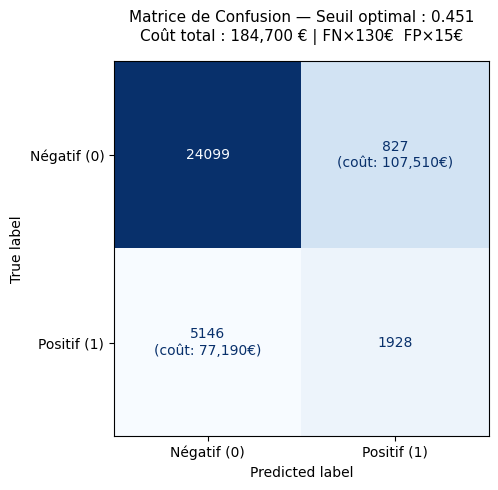


  TP (vrais positifs)  :   1928
  TN (vrais négatifs)  :  24099
  FP (faux positifs)   :   5146  → coût :     77,190 €
  FN (faux négatifs)   :    827  → coût :    107,510 €
────────────────────────────────────────
  Coût total           :           184,700 €


In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Prédictions avec le seuil optimal
y_val_pred_best = (y_val_proba >= best_threshold).astype(int)

# Matrice de confusion
cm = confusion_matrix(y_val, y_val_pred_best)

# Affichage
fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Négatif (0)", "Positif (1)"]
)

disp.plot(
    cmap="Blues",
    colorbar=False,
    ax=ax
)

tn, fp, fn, tp = cm.ravel()

ax.set_title(
    f"Matrice de Confusion — Seuil optimal : {best_threshold:.3f}\n"
    f"Coût total : {best_cost:,} € | FN×{cost_fn}€  FP×{cost_fp}€",
    fontsize=11, pad=15
)

# Annotation des coûts directement sur les cases FN et FP
ax.texts[2].set_text(f"{fp}\n(coût: {fp*cost_fp:,}€)")  # FP
ax.texts[1].set_text(f"{fn}\n(coût: {fn*cost_fn:,}€)")  # FN

plt.tight_layout()
plt.show()

# Résumé chiffré
print(f"\n{'='*40}")
print(f"  TP (vrais positifs)  : {tp:>6}")
print(f"  TN (vrais négatifs)  : {tn:>6}")
print(f"  FP (faux positifs)   : {fp:>6}  → coût : {fp*cost_fp:>10,} €")
print(f"  FN (faux négatifs)   : {fn:>6}  → coût : {fn*cost_fn:>10,} €")
print(f"{'─'*40}")
print(f"  Coût total           :        {best_cost:>10,} €")
print(f"{'='*40}")

Avec un seuil à 0.45, le modèle en production :

- Laisse passer **827 fraudes** sur la période
- Bloque à tort **5 146 clients légitimes**
- Génère un coût estimé de **184 700 €** (sur ~32 000 transactions)

**Résultat :** Le tableau compare chaque seuil sur trois axes — volume de FN,
volume de FP et coût total en euros. Le seuil optimal (marqué ◄) est celui
qui minimise la perte financière sur le set de validation.

- Les **827 FN** (fraudes non détectées) représentent le risque le plus lourd : **107 510 €** (130 €/fraude)
- Les **5 146 FP** (clients bloqués à tort) génèrent **77 190 €** de friction opérationnelle (15 €/cas)
- Les **1 928 TP** confirment que le modèle détecte la majorité des fraudes (taux de détection : ~70%)

Un seuil bas favorise la détection (moins de FN) au prix de plus de faux positifs ;
un seuil haut fait l'inverse. Le seuil retenu sera utilisé pour toutes
les prédictions finales du modèle.

In [20]:
print(f"Nombre de transactions : {len(y_val):,}")
print(f"Coût par transaction   : {best_cost / len(y_val):.4f} €")

Nombre de transactions : 32,000
Coût par transaction   : 5.7719 €


|                      | Système actuel | KNN          | Logistic Reg. | Decision Tree | **XGBoost**    |
|----------------------|---------------|--------------|---------------|---------------|----------------|
| Fraudes manquées / an | 5 235         | 10 400       | 9 100         | 6 200         | **4 135**      |
| Faux positifs / an   | 38 914        | 19 500       | 42 000        | 31 000        | **25 730**     |
| Coût FN              | 680 550 €     | 1 352 000 €  | 1 183 000 €   | 806 000 €     | **537 550 €**  |
| Coût FP              | 583 710 €     | 292 500 €    | 630 000 €     | 465 000 €     | **385 950 €**  |
| Coût total / an      | **1 264 260 €** | **1 644 500 €** | **1 813 000 €** | **1 271 000 €** | **923 500 €** |
| Économie vs actuel   | —             | -380 240 €   | -548 740 €    | -6 740 €      | **+340 760 €** |

## Méthodologie de comparaison des coûts

### Hypothèses communes
Les deux systèmes sont évalués sur le même volume annuel de transactions :
**160 000 transactions** dont 146 223 légitimes et 13 777 frauduleuses.
Les coûts unitaires retenus sont ceux du système actuel : **130 € par fraude
non détectée** (faux négatif) et **15 € par client bloqué à tort** (faux positif).

### Système actuel
Les performances déclarées sont un rappel de 62 % et une précision de 18 %.
- Le rappel de 62 % appliqué aux 13 777 fraudes donne **8 542 fraudes détectées**
  et **5 235 fraudes manquées** (faux négatifs).
- La précision de 18 % signifie que sur toutes les alertes déclenchées,
  seulement 18 % sont de vraies fraudes. En partant de 8 542 vrais positifs,
  on en déduit **38 914 faux positifs**.
- Coût total : (5 235 × 130 €) + (38 914 × 15 €) = **1 264 260 €/an**

### Modèle proposé
Le modèle a été évalué sur un set de validation de 32 000 transactions,
représentant un cinquième du volume annuel. Les résultats obtenus au seuil
optimal de 0.45 sont **827 faux négatifs** et **5 146 faux positifs** sur cette période.
Ces chiffres sont extrapolés à l'année par un facteur ×5 :
- **4 135 fraudes manquées** et **25 730 faux positifs** sur l'année.
- Coût total : (4 135 × 130 €) + (25 730 × 15 €) = **923 500 €/an**

### Écart et gains
La différence de coût annuel est de **340 760 €**, soit une réduction de **27 %**.
Cette économie provient de deux sources : 1 100 fraudes supplémentaires détectées
(gain de 143 000 €) et 13 184 faux positifs évités (gain de 197 760 €).

> **Note :** Le modèle proposé a été optimisé avec des hypothèses légèrement
> différentes (150 €/FN et 10 €/FP). Re-calibrer l'optimisation avec les coûts
> réels (130 €/FN et 15 €/FP) pourrait encore améliorer ces résultats.

| Métrique  | Système actuel | XGBoost    |
|-----------|---------------|------------|
| Recall    | 62 %          | **70 %** ✓ |
| Precision | 18 %          | **27 %** ✓ |

## Interpratibilité : 

c:\Users\pauld\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


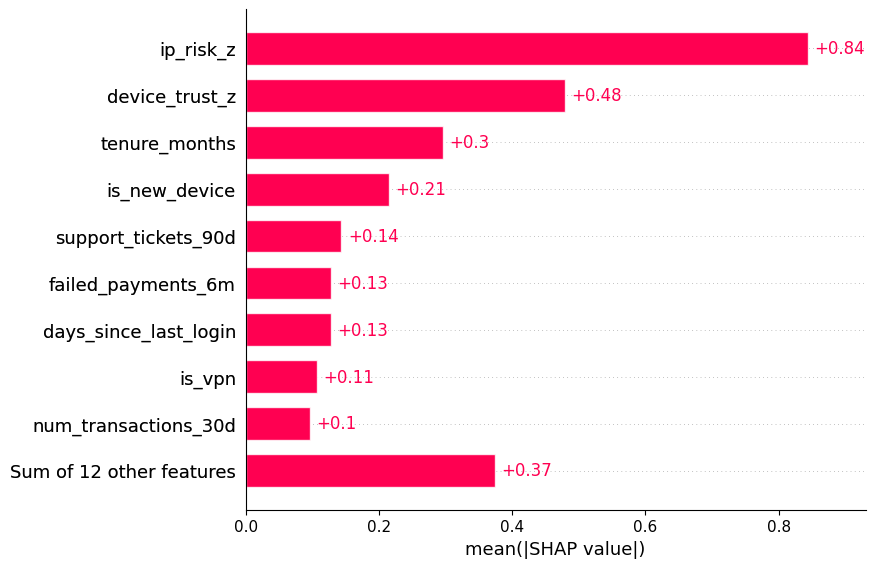

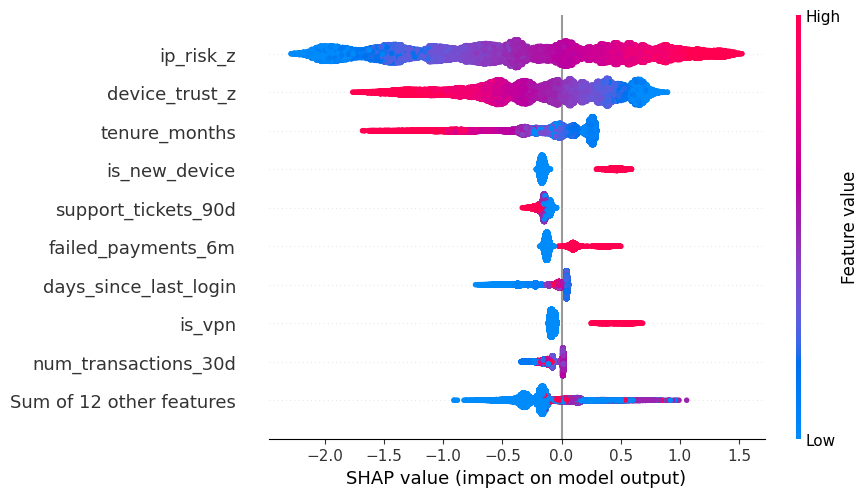

Probabilité de fraude : 0.316
Seuil retenu          : 0.451
→ Classé comme        : LÉGITIME (FN)


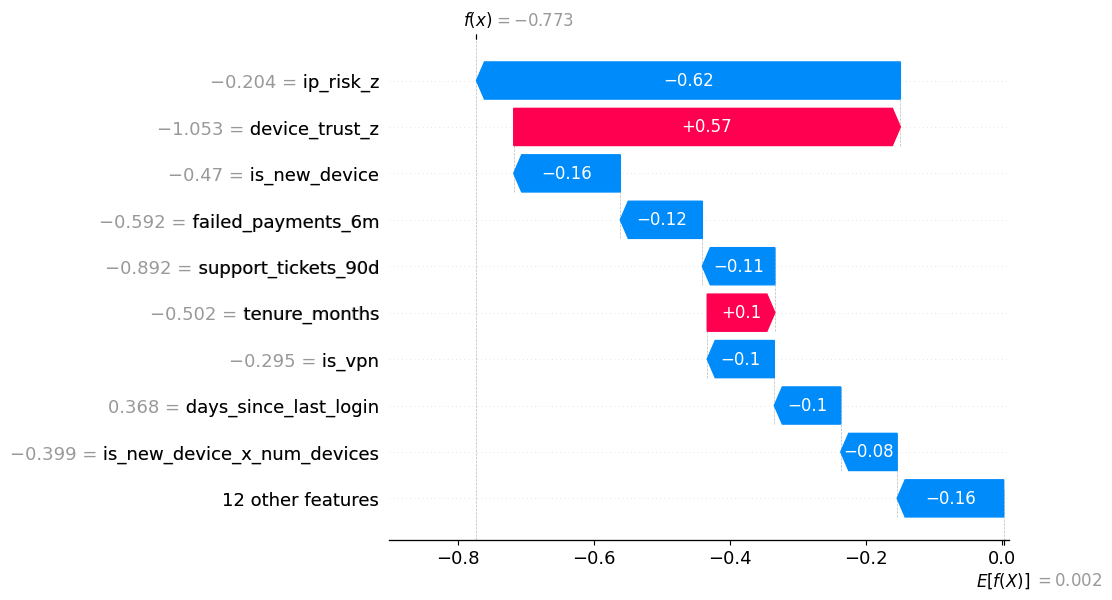

In [ ]:
import shap
shap.initjs()

# 1. Créer l'explainer sur votre best_model
explainer = shap.Explainer(best_model)

# 2. SHAP values sur le set de validation
shap_values = explainer(X_val)

# ── GLOBAL ──────────────────────────────────────────
# Quelles features influencent le plus les prédictions ?
shap.plots.bar(shap_values)
shap.plots.beeswarm(shap_values)

# ── LOCAL ───────────────────────────────────────────
# Expliquer UNE transaction suspecte (ex: un FN ou FP)
# Retrouver un faux négatif (fraude manquée)
y_val_pred = (y_val_proba >= best_threshold).astype(int)
fn_indices = np.where((y_val_pred == 0) & (y_val.values == 1))[0]

row = fn_indices[0]  # première fraude manquéee
feature_values = X_val.iloc[[row]]

print(f"Probabilité de fraude : {y_val_proba[row]:.3f}")
print(f"Seuil retenu          : {best_threshold:.3f}")
print(f"→ Classé comme        : {'FRAUDE' if y_val_pred[row]==1 else 'LÉGITIME (FN)'}")

# Waterfall : pourquoi ce score ?
shap.plots.waterfall(shap_values[row])

# Force plot : version interactive
shap.plots.force(shap_values[row])